In [173]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [174]:
df= pd.read_csv("ford.csv")

EDA

In [175]:
df.head(5)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [176]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [177]:
cols = df.columns
for col in cols:
    print(col)
    print(df[col].value_counts(normalize=True)*100)

model
model
 Fiesta                   36.496716
 Focus                    25.537126
 Kuga                     12.384504
 EcoSport                  6.362017
 C-MAX                     3.022376
 Ka+                       2.955583
 Mondeo                    2.927752
 B-MAX                     1.975955
 S-MAX                     1.647556
 Grand C-MAX               1.374819
 Galaxy                    1.269064
 Edge                      1.157742
 KA                        1.107648
 Puma                      0.445286
 Tourneo Custom            0.384059
 Grand Tourneo Connect     0.328398
 Mustang                   0.317266
 Tourneo Connect           0.183680
 Fusion                    0.089057
 Streetka                  0.011132
 Ranger                    0.005566
 Escort                    0.005566
 Transit Tourneo           0.005566
Focus                      0.005566
Name: proportion, dtype: float64
year
year
2017    27.206946
2018    22.342202
2019    17.778025
2016    12.974507
2015     

In [178]:
df_numeric = df.select_dtypes(include='number')
df_categorical = df.drop(columns=df_numeric.columns)

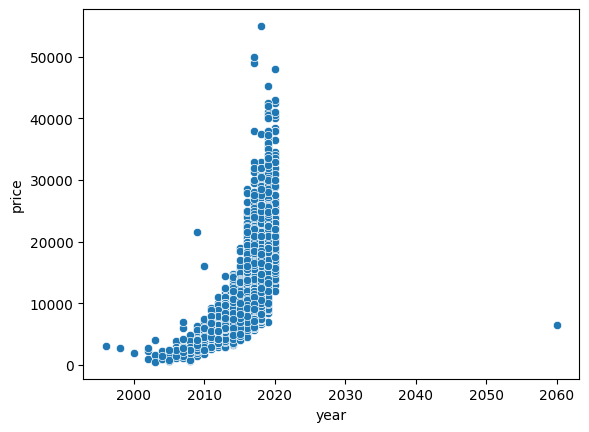

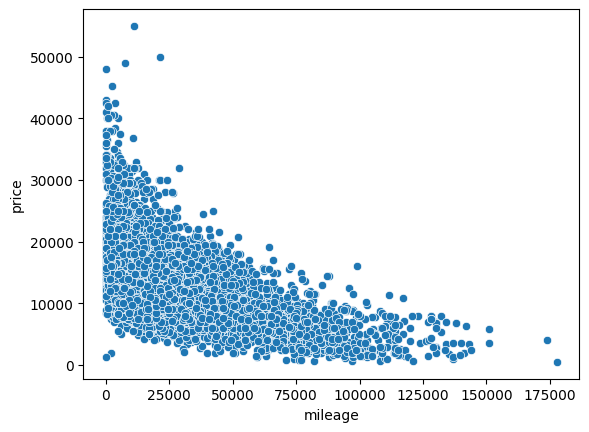

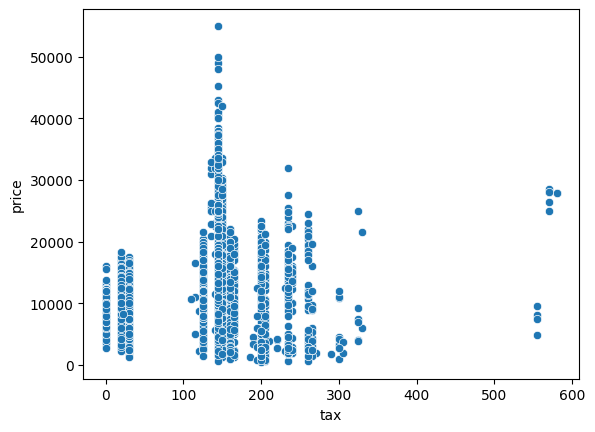

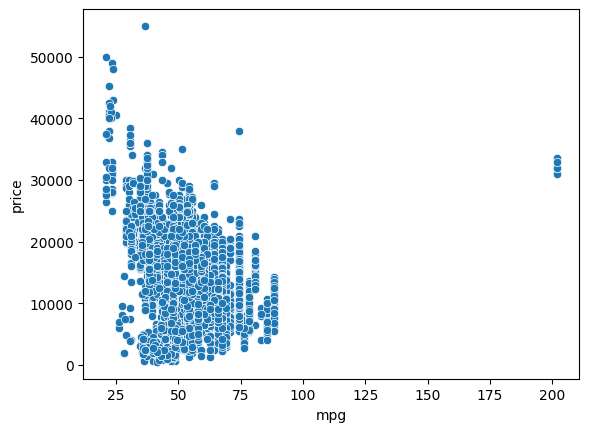

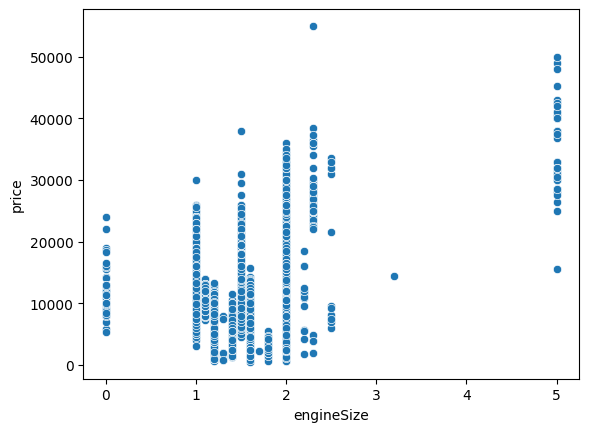

In [179]:
for col in df_numeric:
  if col != "price":
    sns.scatterplot(x=df_numeric[col], y=df_numeric["price"])
    plt.show()

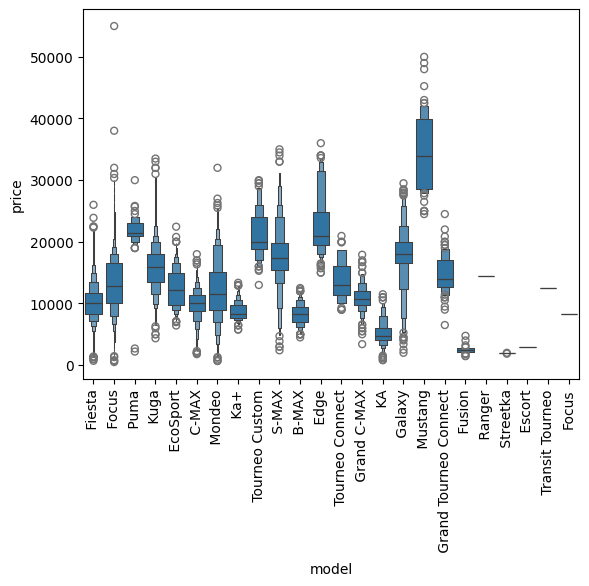

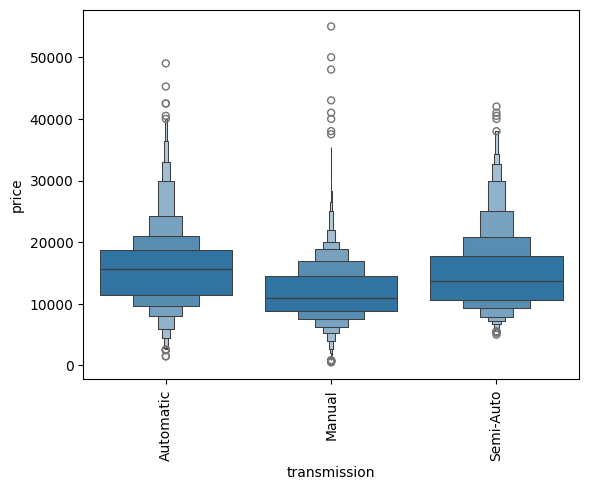

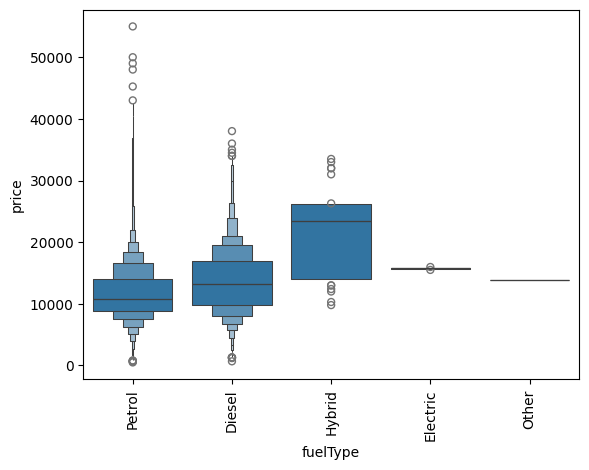

In [180]:
for col in df_categorical:
  sns.boxenplot(x=df_categorical[col], y=df_numeric["price"])
  plt.xticks(rotation=90)
  plt.show()

Spliting data in X and Y

In [181]:
x=df.drop(columns="price",axis=1)
y=df["price"]

Encoding data into (one_hot, lable)

In [182]:
x_encoded=pd.get_dummies(x)

In [183]:
x_encoded

,year,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Transit Tourneo,model_Focus,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
1,2018,9083,150,57.7,1.0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,2017,12456,150,57.7,1.0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,2019,10460,145,40.3,1.5,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,2019,1482,145,48.7,1.0,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47.1,1.4,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
17962,2014,40700,30,57.7,1.0,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
17963,2015,7010,20,67.3,1.6,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
17964,2018,5007,145,57.7,1.2,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [184]:
x_encoded.astype(int)

,year,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Transit Tourneo,model_Focus,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,2017,12456,150,57,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
3,2019,10460,145,40,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,2019,1482,145,48,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
17962,2014,40700,30,57,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
17963,2015,7010,20,67,1,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
17964,2018,5007,145,57,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [185]:
label = LabelEncoder()
x_label_encoded = x.apply(label.fit_transform)

In [186]:
x_label_encoded

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,18,0,5583,4,11,69,1
1,6,19,1,2810,4,11,69,1
2,6,18,1,4208,4,11,69,1
3,5,20,1,3393,4,10,42,6
4,5,20,0,325,4,10,57,1
...,...,...,...,...,...,...,...,...
17961,0,18,1,5868,4,11,55,5
17962,0,15,1,11439,4,3,69,1
17963,6,16,1,2026,0,1,76,7
17964,11,19,1,1311,4,10,69,3


Scaling the data

In [187]:
col_scaling = df.drop(columns=df_categorical,axis=1)
scale = StandardScaler()
x_encoded_scaled =pd.DataFrame(
    scale.fit_transform(x_encoded),
    columns=x_encoded.columns,
    index=x_encoded.index
)
x_label_encoded_scaled = pd.DataFrame(
    scale.fit_transform(x_label_encoded),
    columns=x_label_encoded.columns,
    index=x_label_encoded.index
    )

In [188]:
x_encoded_scaled

,year,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Transit Tourneo,model_Focus,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.380998,0.591358,-0.020442,-0.811386,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.007461,-0.007461,3.492934,-2.517747,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320
1,0.552866,-0.733359,0.591358,-0.020442,-0.811386,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.007461,-0.007461,-0.286292,0.397180,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320
2,0.065128,-0.560132,0.591358,-0.020442,-0.811386,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.007461,-0.007461,-0.286292,0.397180,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320
3,1.040605,-0.662640,0.510727,-1.738890,0.345070,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.007461,-0.007461,-0.286292,0.397180,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320
4,1.040605,-1.123724,0.510727,-0.909294,-0.811386,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.007461,-0.007461,3.492934,-2.517747,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.065128,-0.342172,0.591358,-1.067312,0.113779,7.043327,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.007461,-0.007461,-0.286292,0.397180,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320
17962,-1.398088,0.890398,-1.343791,-0.020442,-0.811386,7.043327,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.007461,-0.007461,-0.286292,0.397180,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320
17963,-0.910349,-0.839822,-1.505053,0.927668,0.576362,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.007461,-0.007461,-0.286292,0.397180,-0.253771,1.455340,-0.010551,-0.035015,-0.007461,-1.450705
17964,0.552866,-0.942690,0.510727,-0.020442,-0.348804,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.007461,-0.007461,-0.286292,0.397180,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320


In [189]:
x_label_encoded_scaled

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460699,0.066945,-2.670032,-0.248712,0.688777,0.630221,0.233741,-0.918707
1,-0.211477,0.561487,0.041351,-0.955118,0.688777,0.630221,0.233741,-0.918707
2,-0.211477,0.066945,0.041351,-0.598985,0.688777,0.630221,0.233741,-0.918707
3,-0.460699,1.056030,0.041351,-0.806602,0.688777,0.418680,-2.075117,0.485538
4,-0.460699,1.056030,-2.670032,-1.588156,0.688777,0.418680,-0.792418,-0.918707
...,...,...,...,...,...,...,...,...
17961,-1.706810,0.066945,0.041351,-0.176110,0.688777,0.630221,-0.963445,0.204689
17962,-1.706810,-1.416684,0.041351,1.243069,0.688777,-1.062112,0.233741,-0.918707
17963,-0.211477,-0.922141,0.041351,-1.154837,-1.454098,-1.485195,0.832333,0.766387
17964,1.034634,0.561487,0.041351,-1.336979,0.688777,0.418680,0.233741,-0.357009


Training the model for (one_hot and Label encoding)

In [190]:
# for one_hot_encoded
x_train, x_test, y_train, y_test = train_test_split(
    x_encoded_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [191]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [192]:
y_predictions = model.predict(x_test)

In [193]:
y_predictions

array([ 6644.59418325,  9190.94182499,  9815.67023063, ...,
       30065.02191131,  9629.26949625, 15117.00750876])

In [194]:
y_test

,price
17610,6995
7076,8999
1713,7998
1611,5491
16830,3790
...,...
7731,22000
11655,13699
10536,24979
11885,10500


In [195]:

r2 = r2_score(y_test, y_predictions)
mse = mean_squared_error(y_test, y_predictions)
n = len(y_test)
p = x_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)


In [196]:
r2*100

84.58422267142565

In [197]:
adj_r2*100

84.42382228864803

In [198]:
mse

3454991.9817439797

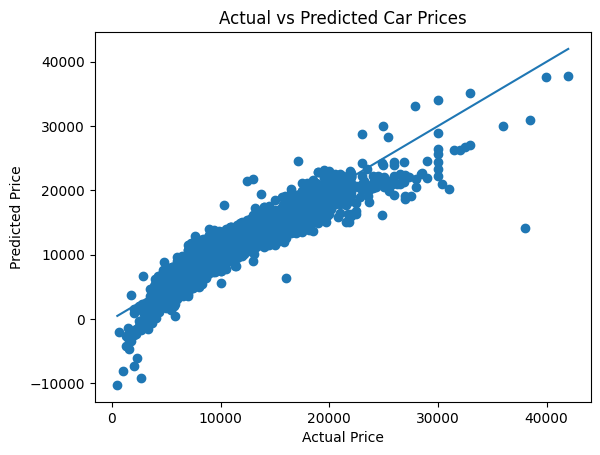

In [199]:
# plot actual vs prediction
plt.scatter(y_test, y_predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

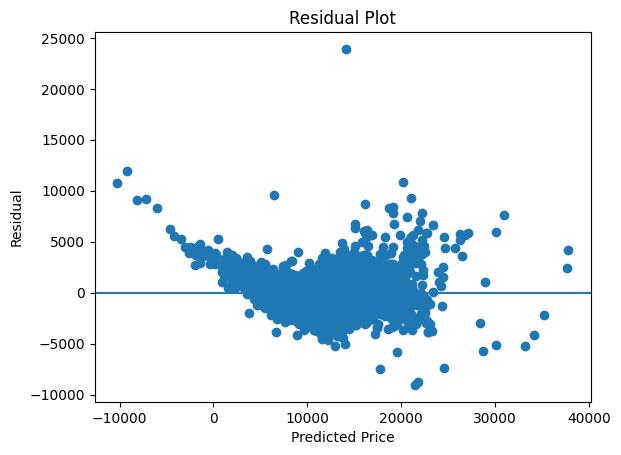

In [200]:
# analyzing residuals
residuals = y_test - y_predictions

plt.scatter(y_predictions, residuals)
plt.axhline(y=0)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

the residualas are random- investigating the large prediction error

In [201]:
largest_error = residuals.abs().sort_values(ascending=False).head()
largest_error.head(10)

,price
1039,23913.348078
13544,11927.665240
10958,10830.828950
17103,10729.884147
14743,9592.528299


In [202]:
error_df = x_test.copy()
error_df["Actual Price"] = y_test
error_df["Predicted Price"] = y_predictions
error_df["Residuals"] = y_test - y_predictions
error_df["Absolute Error"] = error_df['Residuals'].abs()
largest_errors = error_df.sort_values(by="Absolute Error", ascending=False)

In [203]:
largest_errors.head(10)

,year,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Actual Price,Predicted Price,Residuals,Absolute Error
1039,0.065128,-1.189718,0.510727,1.618998,0.345070,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.253771,1.455340,-0.010551,-0.035015,-0.007461,-1.450705,38015,14101.651922,23913.348078,23913.348078
13544,-9.201904,0.700377,0.752620,-1.620376,-0.348804,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320,2699,-9228.665240,11927.665240,11927.665240
10958,1.528343,-1.199322,0.510727,-1.788271,0.345070,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320,30999,20168.171050,10830.828950,10830.828950
17103,-6.763212,7.923442,1.397670,-1.620376,0.576362,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320,495,-10234.884147,10729.884147,10729.884147
14743,-3.349042,0.109257,0.591358,0.216586,0.345070,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320,15999,6406.471701,9592.528299,9592.528299
12351,1.040605,-1.093629,0.591358,-2.311706,2.195401,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320,30359,21067.792542,9291.207458,9291.207458
17282,-8.226427,1.008519,0.752620,-1.620376,-0.117512,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320,1995,-7232.962027,9227.962027,9227.962027
17376,-6.275473,4.500800,0.752620,-1.215454,-0.348804,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320,999,-8120.629093,9119.629093,9119.629093
17537,0.065128,2.052608,-1.827578,0.927668,1.501527,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.253771,-0.687125,-0.010551,28.559348,-0.007461,-1.450705,12400,21447.579915,-9047.579915,9047.579915
4807,-0.422611,0.965636,-1.827578,0.927668,1.501527,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.253771,-0.687125,-0.010551,28.559348,-0.007461,-1.450705,12995,21804.887403,-8809.887403,8809.887403


In [204]:
largest_index = largest_error.head(10).index
df.loc[largest_index]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
1039,Focus,2017,38015,Manual,197,Diesel,145,74.3,1.5
13544,Fiesta,1998,2699,Manual,37000,Petrol,160,41.5,1.2
10958,Focus,2020,30999,Automatic,10,Petrol,145,39.8,1.5
17103,Focus,2003,495,Manual,177644,Petrol,200,41.5,1.6
14743,Kuga,2010,15999,Manual,25490,Petrol,150,60.1,1.5


In [216]:
# This rasidual pattern is caused by simple linear model
# polynimial linear model might be a good fix

In [205]:
# for label encoded
x_train, x_test, y_train, y_test = train_test_split(
    x_label_encoded_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [206]:
model2 = LinearRegression()
model2.fit(x_train, y_train)

LinearRegression()

In [207]:
y_predictions = model2.predict(x_test)

In [208]:
y_predictions

array([ 5556.9228487 ,  8651.19533542,  9384.6792093 , ...,
       22041.14145537,  9146.66161886, 16535.44596845])

In [209]:
y_test

,price
17610,6995
7076,8999
1713,7998
1611,5491
16830,3790
...,...
7731,22000
11655,13699
10536,24979
11885,10500


In [210]:
r2 = r2_score(y_test, y_predictions)
mse = mean_squared_error(y_test, y_predictions)
n = len(y_test)
p = x_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)


In [211]:
r2

0.7380826348787466

In [212]:
adj_r2

0.7374981609816839

In [213]:
mse

5870105.522970265

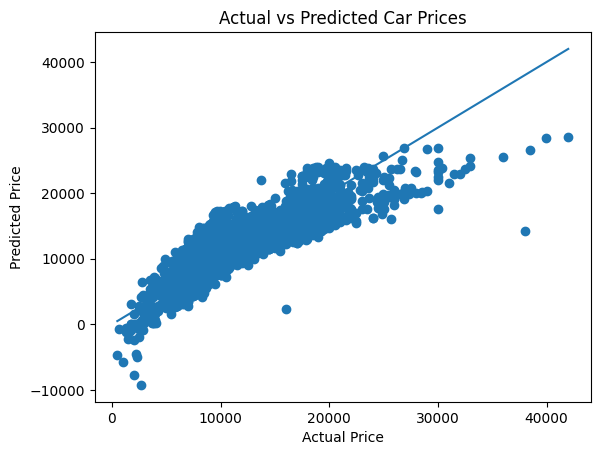

In [214]:
plt.scatter(y_test, y_predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

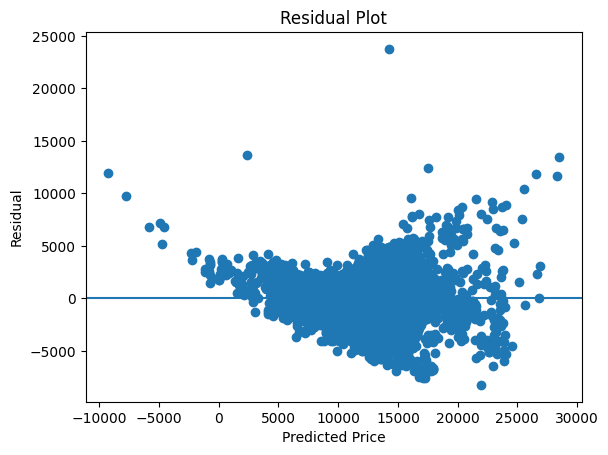

In [215]:
# checking residuals
residuals = y_test - y_predictions

plt.scatter(y_predictions, residuals)
plt.axhline(y=0)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

the rasiduals are radom but there

r2 = higher (one_hot_encoding)
mse = lower(onehot_encoding)
Selecting One_hot_encdoing model